# PART 10. 비즈니스 전략

## 수업 목표
- PART 6~9의 AI 분석 결과를 실무 전략으로 연결합니다.
- 데이터와 AI가 실제 비즈니스 의사결정에 어떻게 쓰이는지 이해합니다.

## 수업 진행 포인트
| 구분 | 설명 |
|---|---|
| 데이터 관점 | 분석 결과를 요약하고 핵심 지표를 확인합니다. |
| 코드 관점 | 지금까지 배운 코드를 종합적으로 활용합니다. |
| AI 관점 | AI 결과를 현업에서 어떻게 의사결정에 연결하는지 정리합니다. |
| 강사 메모 | AI가 정답을 주는 것이 아니라 판단을 돕는다는 점을 강조하세요. |

---

In [ ]:
# 셀 1. Google Drive 연결

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 셀 2. 라이브러리 불러오기

import pandas as pd
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/Olist/data"
print("라이브러리 불러오기 완료!")

라이브러리 불러오기 완료!


In [ ]:
# 셀 3. 통합 데이터 불러오기

df = pd.read_csv(f"{base_path}/olist_master_data.csv")
print("데이터 크기:", df.shape)
df.head()

데이터 크기: (119143, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,14840.0,guariba,SP


In [ ]:
# 셀 4. 쇼핑몰 핵심 지표 요약

print("=== Olist 쇼핑몰 핵심 지표 ===")
print(f"총 주문 건수:    {df['order_id'].nunique():>10,} 건")
print(f"총 고객 수:      {df['customer_unique_id'].nunique():>10,} 명")
print(f"총 상품 수:      {df['product_id'].nunique():>10,} 종")
print(f"총 매출 (BRL):   {df['payment_value'].sum():>10,.0f}")
print(f"평균 리뷰 점수:  {df['review_score'].mean():>10.2f} / 5.0")

=== Olist 쇼핑몰 핵심 지표 ===
총 주문 건수:        99,441 건
총 고객 수:          96,096 명
총 상품 수:          32,951 종
총 매출 (BRL):   20,579,664
평균 리뷰 점수:        4.02 / 5.0


product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: count, dtype: int64


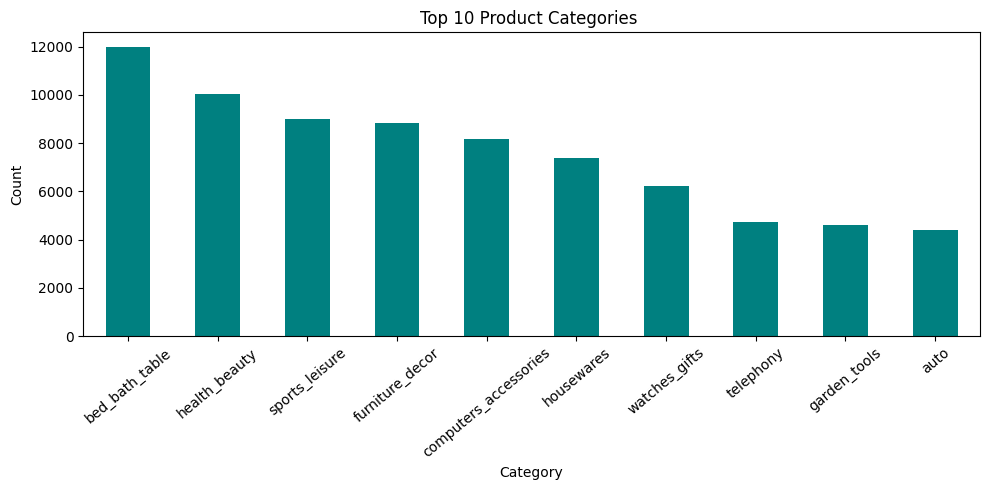

In [17]:
# 셀 5. 인기 상품 카테고리 TOP 10

top_categories = df["product_category_name_english"].value_counts().head(10)
print(top_categories)

top_categories.plot(kind="bar", figsize=(10, 5), color="teal")
plt.title("Top 10 Product Categories ") # 인기 카테고리 TOP 10
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

customer_state
SP    50265
RJ    15518
MG    13819
RS     6573
PR     6043
SC     4345
BA     4091
DF     2516
GO     2466
ES     2360
Name: count, dtype: int64


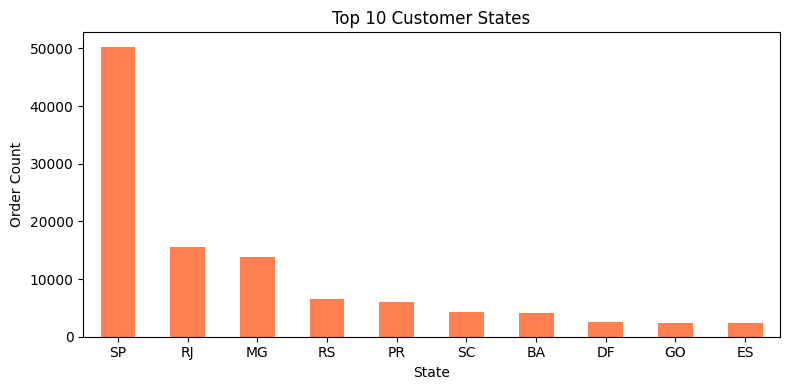

In [16]:
# 셀 6. 지역별 주문 비중 TOP 10

top_states = df["customer_state"].value_counts().head(10)
print(top_states)

top_states.plot(kind="bar", figsize=(8, 4), color="coral")
plt.title("Top 10 Customer States") # 주문 많은 지역
plt.xlabel("State") # 브라질 주
plt.ylabel("Order Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# 셀 7. AI 분석 결과 → 비즈니스 전략 연결표

strategy_df = pd.DataFrame({
    "PART":    ["PART 6",       "PART 7",         "PART 8",       "PART 9"],
    "AI 분석": ["추천 시스템",  "감성 분석",      "매출 예측",    "이탈 예측"],
    "분석 결과": [
        "비슷한 카테고리 상품 추천 가능",
        "리뷰의 긍정/부정 판단 가능",
        "결제 금액 예측 가능",
        "이탈 가능성 높은 고객 식별 가능",
    ],
    "비즈니스 전략": [
        "개인화 추천으로 구매 전환율 향상",
        "부정 리뷰 모니터링 → 서비스 품질 개선",
        "재고 확보 및 프로모션 계획 수립",
        "쿠폰/이벤트로 이탈 고객 재유입",
    ],
})

print(strategy_df.to_string(index=False))

  PART  AI 분석              분석 결과                비즈니스 전략
PART 6 추천 시스템  비슷한 카테고리 상품 추천 가능     개인화 추천으로 구매 전환율 향상
PART 7  감성 분석    리뷰의 긍정/부정 판단 가능 부정 리뷰 모니터링 → 서비스 품질 개선
PART 8  매출 예측        결제 금액 예측 가능     재고 확보 및 프로모션 계획 수립
PART 9  이탈 예측 이탈 가능성 높은 고객 식별 가능      쿠폰/이벤트로 이탈 고객 재유입


In [14]:
# 셀 8. 프로젝트 최종 요약

summary = """
=== STEP1 프로젝트 최종 요약 ===

  [데이터] Olist 브라질 이커머스 (2016~2018, 약 10만 건)

  [분석 흐름]
    PART 1  → 데이터셋 소개
    PART 2  → 데이터 다운로드 및 저장
    PART 3  → 데이터 구조 이해
    PART 4  → 9개 CSV → 1개 통합 파일 병합
    PART 5  → EDA: 매출 추이, 리뷰, 인기 카테고리
    PART 6  → 추천 시스템 (카테고리 유사도)
    PART 7  → 감성 분석 (NLP + BERT)
    PART 8  → 매출 예측 (RandomForest 회귀)
    PART 9  → 이탈 예측 (RandomForest 분류)
    PART 10 → AI 결과 → 비즈니스 전략 연결

  [저장 파일]
    olist_master_data.csv         → 통합 데이터
    part6_recommend_model.pkl     → 추천 모델
    part7_sentiment_model.h5      → 감성분석 모델
    part7_tokenizer.pkl           → 감성분석 Tokenizer
    part8_sales_model.pkl         → 매출 예측 모델
    part9_churn_model.pkl         → 이탈 예측 모델

  → STEP2에서 AI 모델을 로컬에서 웹 화면(Gradio)과 연결하고 (서빙)
  → STEP3에서는 Hugging Face에 배포합니다.
"""
print(summary)


=== STEP1 프로젝트 최종 요약 ===

  [데이터] Olist 브라질 이커머스 (2016~2018, 약 10만 건)

  [분석 흐름]
    PART 1  → 데이터셋 소개
    PART 2  → 데이터 다운로드 및 저장
    PART 3  → 데이터 구조 이해
    PART 4  → 9개 CSV → 1개 통합 파일 병합
    PART 5  → EDA: 매출 추이, 리뷰, 인기 카테고리
    PART 6  → 추천 시스템 (카테고리 유사도)
    PART 7  → 감성 분석 (NLP + BERT)
    PART 8  → 매출 예측 (RandomForest 회귀)
    PART 9  → 이탈 예측 (RandomForest 분류)
    PART 10 → AI 결과 → 비즈니스 전략 연결

  [저장 파일]
    olist_master_data.csv         → 통합 데이터
    part6_recommend_model.pkl     → 추천 모델
    part7_sentiment_model.h5      → 감성분석 모델
    part7_tokenizer.pkl           → 감성분석 Tokenizer
    part8_sales_model.pkl         → 매출 예측 모델
    part9_churn_model.pkl         → 이탈 예측 모델

  → STEP2에서 AI 모델을 로컬에서 웹 화면(Gradio)과 연결하고 (서빙)
  → STEP3에서는 Hugging Face에 배포합니다.



---

## 마무리 정리

| 확인할 내용 | 설명 |
|---|---|
| 이 파트의 핵심 | AI 결과를 실무 전략으로 연결합니다. |
| 핵심 메시지 | AI는 정답을 주는 것이 아니라 더 나은 판단을 돕는 도구입니다. |
| 다음 단계 | STEP2에서 학습된 모델을 로컬에서 Gradio 화면과 연결하여 서빙합니다. |
| 그 다음 단계 | STEP3에서 Hugging Face Spaces에 배포합니다. |

##### 모델 → Gradio UI → Hugging Face Spaces


##### 모델 학습 → 화면 연결 → 실제 배포

## STEP1 완료